# Evaluating the Impact of Image Augmentation Strategies on CNN Architectures in Skin Lesion Classification

**DS 6050, SP 2026 - ML III: Deep Learning Project** *For Professor Heman Shakeri, PhD, University of Virginia*

---

### Team Members
* **Robert Ashby** | *University of Virginia, School of Data Science* | Fernandina Beach, Florida | gsr3qz@virginia.edu
* **Xavier Colbert** | *University of Virginia, School of Data Science* | Alexandria, Virginia | kxp3jj@virginia.edu
* **Jacob Kuchta** | *University of Virginia, School of Data Science* | Arlington, Virginia | mjk3ku@virginia.edu
* **Alysa Pugmire** | *University of Virginia, School of Data Science* | Richmond, Virginia | amp3xs@virginia.edu

## Notebook 05 — Metadata Fusion (Late Fusion MLP)

This notebook runs the metadata fusion experiment using the winning backbone and augmentation combination identified in `04_ablation_study.ipynb`.

**Approach:** A small 2-layer MLP (13 → 32 → 16, ReLU, Dropout) processes patient metadata (age, sex, anatomical site) independently. Its output is concatenated with the CNN's Global Average Pooling features before the final classifier. This is late fusion — the image and metadata are processed separately and combined only at the decision stage.

**Research question (RQ3):** Does late-fusion metadata contribute additional predictive value beyond image-only learning?

**How to interpret results:** The delta in macro-AUC and BACC between this notebook and the notebook 04 winner quantifies the metadata contribution:
```
metadata_gain_auc  = notebook05_auc  - notebook04_winner_auc
metadata_gain_bacc = notebook05_bacc - notebook04_winner_bacc
```

**Metadata columns (confirmed from processed CSVs):**
```
age_scaled (1) + sex_* (3) + anatom_site_general_* (9) = 13 features total
```

## Configuration

Update `WINNING_BACKBONE`, `WINNING_COMBO`, and the notebook 04 reference scores once the ablation study completes.

In [1]:
# ============================================================
# UPDATE THESE AFTER NOTEBOOK 04 IDENTIFIES THE WINNER
# ============================================================
WINNING_BACKBONE = "efficientnet_b0"
WINNING_COMBO    = "baseline"

# Reference scores from notebook 04 winner — fill in after 04 completes
NOTEBOOK04_WINNER_AUC  = 0.9631
NOTEBOOK04_WINNER_BACC = 0.7703

# ============================================================
# TRAINING CONFIG
# ============================================================
SEED             = 42
IMAGE_SIZE       = 224
BATCH_SIZE       = 32
EPOCHS           = 20
LEARNING_RATE    = 1e-4
WEIGHT_DECAY     = 1e-4
NUM_WORKERS      = 0
FREEZE_FEATURES  = False
SAVE_CHECKPOINTS = True
METADATA_DIM     = 13

## Imports and project root setup

In [2]:
from pathlib import Path
import sys
import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import balanced_accuracy_score, roc_auc_score, confusion_matrix, classification_report

cwd     = Path.cwd().resolve()
ROOT    = cwd.parent if cwd.name.lower() == "code" else cwd
SCRIPTS = ROOT / "scripts"

if str(SCRIPTS) not in sys.path:
    sys.path.append(str(SCRIPTS))

from efficientnet_b0_baseline import build_efficientnet_b0
from resnet50_baseline        import build_resnet50
from densenet121_baseline     import build_densenet121

from phase2_geometric  import build_phase2_transform
from phase3_color      import build_phase3_transform
from phase4_scale_crop import build_phase4_transform, cutmix_data, cutmix_loss

MODEL_BUILDERS = {
    "resnet50":        build_resnet50,
    "efficientnet_b0": build_efficientnet_b0,
    "densenet121":     build_densenet121,
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("ROOT:", ROOT)
print("DEVICE:", DEVICE)
print("Winning backbone:", WINNING_BACKBONE)
print("Winning combo:", WINNING_COMBO)

ROOT: /sfs/weka/scratch/mjk3ku/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire
DEVICE: cuda
Winning backbone: efficientnet_b0
Winning combo: baseline


## Output directories

In [3]:
OUT_ROOT   = ROOT / "outputs"
CKPT_DIR   = OUT_ROOT / "checkpoints"
FIG_DIR    = OUT_ROOT / "figures" / "05_metadata_fusion"
METRIC_DIR = OUT_ROOT / "metrics"
PRED_DIR   = OUT_ROOT / "preds"
REPORT_DIR = OUT_ROOT / "reports" / "05_metadata_fusion"

for d in [CKPT_DIR, FIG_DIR, METRIC_DIR, PRED_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Output dirs ready.")

Output dirs ready.


## Load processed ISIC 2019 splits

In [4]:
DATA      = ROOT / "DATA"
PROCESSED = DATA / "processed"

train_csv    = PROCESSED / "isic2019" / "train.csv"
val_csv      = PROCESSED / "isic2019" / "val.csv"
weights_json = PROCESSED / "class_weights.json"

train_df = pd.read_csv(train_csv)
val_df   = pd.read_csv(val_csv)

def normalize_path_column(df, col):
    df = df.copy()
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace("\\", "/", regex=False)
    return df

train_df = normalize_path_column(train_df, "image_path")
val_df   = normalize_path_column(val_df,   "image_path")

labels       = sorted(train_df["label"].unique())
label_to_idx = {label: idx for idx, label in enumerate(labels)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

train_df["label_idx"] = train_df["label"].map(label_to_idx)
val_df["label_idx"]   = val_df["label"].map(label_to_idx)

with open(weights_json, "r") as f:
    class_weights_dict = json.load(f)

class_weight_tensor = torch.tensor(
    [class_weights_dict[label] for label in labels],
    dtype=torch.float32,
    device=DEVICE,
)

print("Labels:", labels)
print("Train shape:", train_df.shape)
print("Val shape:  ", val_df.shape)

Labels: ['AK', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'VASC']
Train shape: (21531, 22)
Val shape:   (3800, 22)


## ISICDataset — with metadata

Key difference from notebooks 02 and 04: `__getitem__` now returns a `metadata_tensor` alongside the image. The 13 META_COLS are the encoded columns confirmed from our processed CSVs.

The return statement is:
```python
return image, label, rel_path, metadata_tensor
```

In [5]:
META_COLS = [
    "age_scaled",
    "sex_female", "sex_male", "sex_unknown",
    "anatom_site_general_anterior torso",
    "anatom_site_general_head/neck",
    "anatom_site_general_lateral torso",
    "anatom_site_general_lower extremity",
    "anatom_site_general_oral/genital",
    "anatom_site_general_palms/soles",
    "anatom_site_general_posterior torso",
    "anatom_site_general_unknown",
    "anatom_site_general_upper extremity",
]  # 13 features — matches METADATA_DIM = 13


class ISICDataset(Dataset):
    def __init__(self, df, root, transform=None):
        self.df        = df.reset_index(drop=True).copy()
        self.root      = Path(root)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        rel_path = str(row["image_path"]).replace("\\", "/")
        image    = Image.open(self.root / rel_path).convert("RGB")
        label    = int(row["label_idx"])

        if self.transform is not None:
            image = self.transform(image)

        # metadata tensor — 13 encoded features from processed CSV
        metadata_tensor = torch.tensor(
            row[META_COLS].values.astype(float),
            dtype=torch.float32
        )

        return image, label, rel_path, metadata_tensor

## Winning augmentation transform

Mirrors the transform construction from notebook 04. Uses `WINNING_COMBO` defined at the top. Order: resize → augmentation → ToTensor → Normalize.

In [6]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


def get_val_transform(image_size=IMAGE_SIZE):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])


def get_winning_train_transform(combo, image_size=IMAGE_SIZE):
    """
    Builds the training transform pipeline for the winning combo.
    Order: resize -> augmentation -> ToTensor -> Normalize
    """
    base_ops          = [transforms.Resize((image_size, image_size))]
    to_tensor_norm    = [
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]

    if combo == "baseline":
        return transforms.Compose(base_ops + to_tensor_norm)

    aug_ops = list(base_ops)

    if combo in ["phase1_plus_2", "phase1_plus_2_plus_3", "phase1_plus_2_plus_3_plus_4"]:
        aug_ops = build_phase2_transform(aug_ops).transforms

    if combo in ["phase1_plus_2_plus_3", "phase1_plus_2_plus_3_plus_4"]:
        aug_ops = build_phase3_transform(
            aug_ops, brightness=0.2, contrast=0.2, hue=0.1, saturation=0.2
        ).transforms

    if combo == "phase1_plus_2_plus_3_plus_4":
        aug_ops = build_phase4_transform(
            aug_ops, size=image_size, scale=(0.7, 1.0), ratio=(3/4, 4/3)
        ).transforms

    return transforms.Compose(list(aug_ops) + to_tensor_norm)


USE_CUTMIX  = "plus_4" in WINNING_COMBO
train_tf    = get_winning_train_transform(WINNING_COMBO, IMAGE_SIZE)
val_tf      = get_val_transform(IMAGE_SIZE)

print("Train transform built for combo:", WINNING_COMBO)
print("Use CutMix:", USE_CUTMIX)

Train transform built for combo: baseline
Use CutMix: False


## Datasets and DataLoaders

In [7]:
train_ds = ISICDataset(train_df, ROOT, transform=train_tf)
val_ds   = ISICDataset(val_df,   ROOT, transform=val_tf)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Train size:", len(train_ds))
print("Val size:  ", len(val_ds))

# Sanity check — verify metadata comes through correctly
sample_img, sample_label, sample_path, sample_meta = train_ds[0]
print("Sample image shape:", sample_img.shape)
print("Sample metadata shape:", sample_meta.shape)  # should be torch.Size([13])
print("Sample metadata tensor:", sample_meta)


Train size: 21531
Val size:   3800
Sample image shape: torch.Size([3, 224, 224])
Sample metadata shape: torch.Size([13])
Sample metadata tensor: tensor([-0.7834,  0.0000,  1.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000])


## Build model with metadata fusion

The only difference from notebooks 02 and 04 is `use_metadata=True`. The `MetadataMLP` branch inside the model processes the 13-dim metadata vector to a 16-dim embedding, which gets concatenated with the CNN's 1280-dim GAP features before the classifier.

In [8]:
build_fn = MODEL_BUILDERS[WINNING_BACKBONE]
model    = build_fn(
    num_classes=len(labels),
    pretrained=True,
    freeze_backbone=FREEZE_FEATURES,
    use_metadata=True,        # ← metadata fusion enabled
    metadata_dim=METADATA_DIM,
).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weight_tensor)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

print("Model built:", WINNING_BACKBONE, "with use_metadata=True")

Model built: efficientnet_b0 with use_metadata=True


## Training and evaluation utilities

Same structure as notebook 04 with one key difference: the training loop unpacks `metadata` from the loader and passes it to `model(images, metadata)`.

In [9]:
def maybe_apply_cutmix(x, y, cutmix_prob=0.5, alpha=1.0):
    if alpha <= 0:
        return x, y, y, 1.0
    if np.random.rand() > cutmix_prob:
        return x, y, y, 1.0
    return cutmix_data(x, y, alpha=alpha)


def train_one_epoch(model, loader, criterion, optimizer, device, use_cutmix=False):
    model.train()
    running_loss = 0.0
    n_samples    = 0

    for images, targets, _, metadata in loader:  # ← unpack metadata
        images   = images.to(device)
        targets  = targets.to(device)
        metadata = metadata.to(device)           # ← move metadata to GPU

        optimizer.zero_grad()

        if use_cutmix:
            images, y_a, y_b, lam = maybe_apply_cutmix(images, targets)
            logits = model(images, metadata)      # ← pass metadata to model
            loss   = cutmix_loss(criterion, logits, y_a, y_b, lam)
        else:
            logits = model(images, metadata)      # ← pass metadata to model
            loss   = criterion(logits, targets)

        loss.backward()
        optimizer.step()

        batch_size    = images.size(0)
        running_loss += loss.item() * batch_size
        n_samples    += batch_size

    return running_loss / max(n_samples, 1)

In [10]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    n_samples    = 0
    all_targets  = []
    all_preds    = []
    all_probs    = []
    all_paths    = []

    for images, targets, paths, metadata in loader:  # ← unpack metadata
        images   = images.to(device)
        targets  = targets.to(device)
        metadata = metadata.to(device)               # ← move metadata to GPU

        logits = model(images, metadata)              # ← pass metadata to model
        loss   = criterion(logits, targets)
        probs  = torch.softmax(logits, dim=1)
        preds  = torch.argmax(probs, dim=1)

        batch_size    = images.size(0)
        running_loss += loss.item() * batch_size
        n_samples    += batch_size

        all_targets.extend(targets.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_paths.extend(paths)

    avg_loss = running_loss / max(n_samples, 1)
    y_true   = np.array(all_targets)
    y_pred   = np.array(all_preds)
    y_prob   = np.array(all_probs)

    bal_acc = balanced_accuracy_score(y_true, y_pred)

    try:
        macro_auc = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
    except ValueError:
        macro_auc = np.nan

    # Per-class AUC
    per_class_auc = {}
    for i, label in enumerate(labels):
        try:
            per_class_auc[label] = roc_auc_score(
                (y_true == i).astype(int), y_prob[:, i]
            )
        except ValueError:
            per_class_auc[label] = np.nan

    cm_counts   = confusion_matrix(y_true, y_pred, labels=list(range(len(labels))))
    cm_row_norm = confusion_matrix(
        y_true, y_pred, labels=list(range(len(labels))), normalize="true"
    )

    report_dict = classification_report(
        y_true, y_pred,
        labels=list(range(len(labels))),
        target_names=labels,
        output_dict=True,
        zero_division=0,
    )

    return {
        "loss":                avg_loss,
        "balanced_accuracy":   bal_acc,
        "macro_auc":           macro_auc,
        "per_class_auc":       per_class_auc,
        "y_true":              y_true,
        "y_pred":              y_pred,
        "y_prob":              y_prob,
        "paths":               all_paths,
        "cm_counts":           cm_counts,
        "cm_row_norm":         cm_row_norm,
        "classification_report": report_dict,
    }

## Training loop

In [11]:
tag            = f"{WINNING_BACKBONE}_{WINNING_COMBO}_metadata"
best_ckpt_path = CKPT_DIR   / f"{tag}_best.pt"
history_path   = METRIC_DIR / f"{tag}_history.csv"
pred_path      = PRED_DIR   / f"{tag}_predictions.csv"
report_path    = REPORT_DIR / f"{tag}_classification_report.json"

history = {
    "epoch":                   [],
    "epoch_seconds":           [],
    "train_loss":              [],
    "val_loss":                [],
    "val_balanced_accuracy":   [],
    "val_macro_auc":           [],
}

best_score       = -np.inf
best_val_metrics = None
best_epoch       = None
model_start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    train_loss  = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE, use_cutmix=USE_CUTMIX
    )
    val_metrics = evaluate(model, val_loader, criterion, DEVICE)
    epoch_seconds = time.time() - epoch_start

    current_score = val_metrics["macro_auc"]
    if np.isnan(current_score):
        current_score = val_metrics["balanced_accuracy"]

    if current_score > best_score:
        best_score       = current_score
        best_val_metrics = val_metrics
        best_epoch       = epoch

        if SAVE_CHECKPOINTS:
            torch.save(
                {
                    "epoch":            epoch,
                    "model_state_dict": model.state_dict(),
                    "label_to_idx":     label_to_idx,
                    "backbone":         WINNING_BACKBONE,
                    "combo":            WINNING_COMBO,
                    "use_metadata":     True,
                    "image_size":       IMAGE_SIZE,
                },
                best_ckpt_path,
            )

    history["epoch"].append(epoch)
    history["epoch_seconds"].append(epoch_seconds)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["val_balanced_accuracy"].append(val_metrics["balanced_accuracy"])
    history["val_macro_auc"].append(val_metrics["macro_auc"])

    print(
        f"{WINNING_BACKBONE} | metadata | Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_bal_acc={val_metrics['balanced_accuracy']:.4f} | "
        f"val_macro_auc={val_metrics['macro_auc']:.4f} | "
        f"epoch_time={epoch_seconds/60:.2f} min"
    )

total_minutes = (time.time() - model_start_time) / 60
print(f"\nFinished in {total_minutes:.2f} minutes")
print(f"Best epoch: {best_epoch} | Best AUC: {best_score:.4f}")

history_df = pd.DataFrame(history)
history_df.to_csv(history_path, index=False)

efficientnet_b0 | metadata | Epoch 01 | train_loss=1.3512 | val_loss=0.9158 | val_bal_acc=0.6879 | val_macro_auc=0.9339 | epoch_time=5.17 min


efficientnet_b0 | metadata | Epoch 02 | train_loss=0.8325 | val_loss=0.8109 | val_bal_acc=0.7169 | val_macro_auc=0.9479 | epoch_time=4.66 min


efficientnet_b0 | metadata | Epoch 03 | train_loss=0.6145 | val_loss=0.7289 | val_bal_acc=0.7431 | val_macro_auc=0.9570 | epoch_time=4.63 min


efficientnet_b0 | metadata | Epoch 04 | train_loss=0.4605 | val_loss=0.7287 | val_bal_acc=0.7539 | val_macro_auc=0.9632 | epoch_time=4.62 min


efficientnet_b0 | metadata | Epoch 05 | train_loss=0.3537 | val_loss=0.7055 | val_bal_acc=0.7525 | val_macro_auc=0.9659 | epoch_time=4.61 min


...

efficientnet_b0 | metadata | Epoch 16 | train_loss=0.0784 | val_loss=0.9228 | val_bal_acc=0.7899 | val_macro_auc=0.9728 | epoch_time=4.58 min


efficientnet_b0 | metadata | Epoch 17 | train_loss=0.0741 | val_loss=0.9899 | val_bal_acc=0.7849 | val_macro_auc=0.9718 | epoch_time=4.61 min


efficientnet_b0 | metadata | Epoch 18 | train_loss=0.0746 | val_loss=0.9945 | val_bal_acc=0.7724 | val_macro_auc=0.9704 | epoch_time=4.58 min


efficientnet_b0 | metadata | Epoch 19 | train_loss=0.0935 | val_loss=1.0130 | val_bal_acc=0.7699 | val_macro_auc=0.9702 | epoch_time=4.62 min


efficientnet_b0 | metadata | Epoch 20 | train_loss=0.0819 | val_loss=0.9599 | val_bal_acc=0.7830 | val_macro_auc=0.9731 | epoch_time=4.64 min

Finished in 92.79 minutes
Best epoch: 20 | Best AUC: 0.9731


## Results and metadata gain

In [12]:
final_auc  = best_val_metrics["macro_auc"]
final_bacc = best_val_metrics["balanced_accuracy"]

print("=" * 60)
print("  Metadata Fusion Results")
print("=" * 60)
print(f"  Backbone:      {WINNING_BACKBONE}")
print(f"  Combo:         {WINNING_COMBO}")
print(f"  Best epoch:    {best_epoch}")
print(f"  Macro AUC:     {final_auc:.4f}")
print(f"  Balanced Acc:  {final_bacc:.4f}")
print()

if NOTEBOOK04_WINNER_AUC is not None:
    gain_auc  = final_auc  - NOTEBOOK04_WINNER_AUC
    gain_bacc = final_bacc - NOTEBOOK04_WINNER_BACC
    print(f"  Notebook 04 reference AUC:  {NOTEBOOK04_WINNER_AUC:.4f}")
    print(f"  Notebook 04 reference BACC: {NOTEBOOK04_WINNER_BACC:.4f}")
    print()
    print(f"  Metadata gain AUC:   {gain_auc:+.4f}")
    print(f"  Metadata gain BACC:  {gain_bacc:+.4f}")
else:
    print("  (Fill in NOTEBOOK04_WINNER_AUC and NOTEBOOK04_WINNER_BACC to see the metadata gain delta)")

print("=" * 60)

# Per-class AUC
print("\nPer-class AUC:")
for label, auc in best_val_metrics["per_class_auc"].items():
    print(f"  {label:6s}: {auc:.4f}")

# Save classification report
with open(report_path, "w") as f:
    json.dump(best_val_metrics["classification_report"], f, indent=2)
print("\nClassification report saved to:", report_path)

  Metadata Fusion Results
  Backbone:      efficientnet_b0
  Combo:         baseline
  Best epoch:    20
  Macro AUC:     0.9731
  Balanced Acc:  0.7830

  Notebook 04 reference AUC:  0.9631
  Notebook 04 reference BACC: 0.7703

  Metadata gain AUC:   +0.0100
  Metadata gain BACC:  +0.0127

Per-class AUC:
  AK    : 0.9768
  BCC   : 0.9851
  BKL   : 0.9532
  DF    : 0.9879
  MEL   : 0.9394
  NV    : 0.9676
  SCC   : 0.9755
  VASC  : 0.9994

Classification report saved to: /sfs/weka/scratch/mjk3ku/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/outputs/reports/05_metadata_fusion/efficientnet_b0_baseline_metadata_classification_report.json


## Training curves

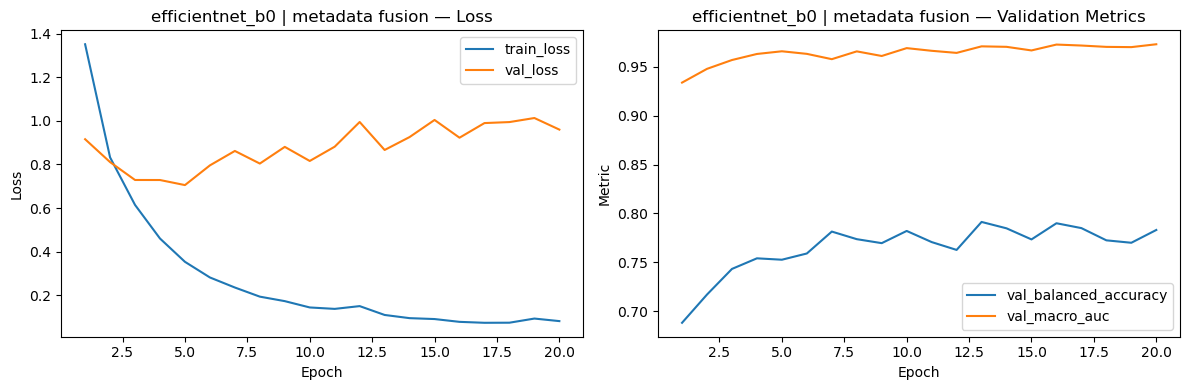

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"],   label="val_loss")
axes[0].set_title(f"{WINNING_BACKBONE} | metadata fusion — Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["val_balanced_accuracy"], label="val_balanced_accuracy")
axes[1].plot(history_df["epoch"], history_df["val_macro_auc"],         label="val_macro_auc")
axes[1].set_title(f"{WINNING_BACKBONE} | metadata fusion — Validation Metrics")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Metric")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / f"{tag}_curves.png", dpi=200, bbox_inches="tight")
plt.show()

## Confusion matrix

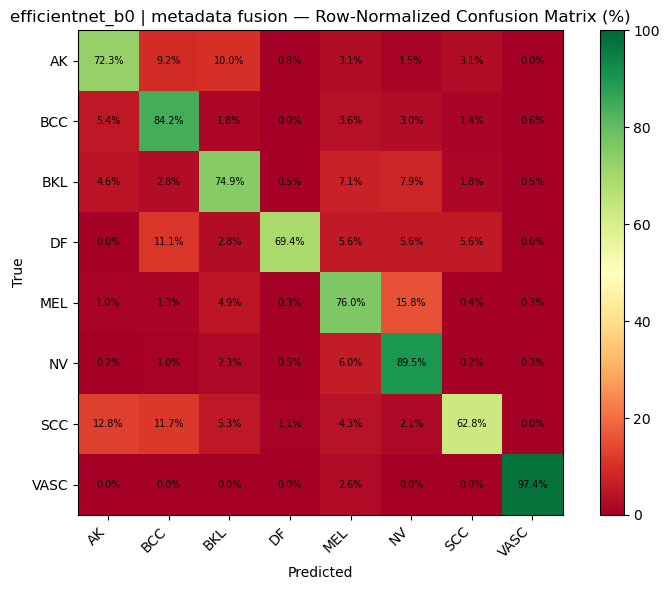

In [14]:
cm_pct = best_val_metrics["cm_row_norm"] * 100

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_pct, cmap="RdYlGn", vmin=0, vmax=100)
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"{WINNING_BACKBONE} | metadata fusion — Row-Normalized Confusion Matrix (%)")

for i in range(cm_pct.shape[0]):
    for j in range(cm_pct.shape[1]):
        ax.text(j, i, f"{cm_pct[i, j]:.1f}%",
                ha="center", va="center", fontsize=7)

fig.colorbar(im)
plt.tight_layout()
plt.savefig(FIG_DIR / f"{tag}_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

## Next Steps

The best model from this notebook feeds directly into `06_external_evaluation.ipynb`.

In notebook 06:
- Load the checkpoint saved at `best_ckpt_path`
- Run inference on the MILK10K external validation set
- Compute `∆gen = BACC_ISIC_val - BACC_MILK10K` to measure generalization gap
- Compare generalization gap with and without metadata fusion